# Brain Tumor Detection Using CNN

## Import Modules

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch # PyTorch package
import torchvision
import torchvision.transforms as transforms # transform data
import torch.nn as nn # basic building block for neural neteorks
import torch.nn.functional as F # import convolution functions like Relu
import torch.optim as optim # optimzer
from torchvision import datasets
import torch.autograd 
from tqdm import tqdm
import os
import cv2 as cv2
import pandas as pd
from PIL import Image


## General info of dataset

The Brain MRI Image for Brain Tumor Detection from Kaggle has the following folders and images.

Train folder has 253 images of 2 classes (glioma_tumor, meningioma_tumor, pituitary_tumor) and 155 images of no_tumor class.

## Loading and normalize data

In [110]:
data_transform = transforms.Compose(
[
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.Resize((500, 500))]) # mean and std
    


# Bacth size
batch_size = 6

# set number of workers
num_workers = 2


# loading training data
trainset = datasets.ImageFolder(root='./data/train',
                                           transform=data_transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)


# loading test data
testset = datasets.ImageFolder(root='./data/test',
                                           transform=data_transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)



## Visualize Images

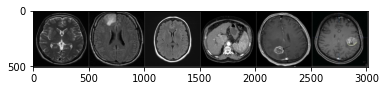

In [111]:
def imshow(img):
    """
        Function to visualize images
    """
    img = img / 2 + 0.5 
    img_np = img.numpy()
    plt.imshow(np.transpose(img_np, (1,2,0)))
    plt.show()
    
# get random training images with iter function
dataiter = iter(trainloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images))



## Define Network

In [122]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 6, 5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),
            
            # Second layer
            nn.Conv2d(6, 1, 5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),
     
        )
        
        self.fcnn = nn.Sequential(
            nn.Flatten(),
            nn.Linear(14884,1)
            
        )
        
    def forward(self, x):
        x = self.cnn(x)
        x = self.fcnn(x)
        
        return x
    
    
model = Net()


# defining the optimizer
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# defining the loss function
criterion = nn.CrossEntropyLoss()


print(model)        
        
       
        

Net(
  (cnn): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 1, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fcnn): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=14884, out_features=1, bias=True)
  )
)


In [120]:
loss_fn = torch.nn.BCELoss()

def train(epoch):

    running_loss = 0.
    last_loss = 0.


    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(trainloader):
        # Every data instance is an input + label pair
        inputs, labels = data
        
        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs)

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(training_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.

    return last_loss

train(0)

ValueError: Using a target size (torch.Size([6])) that is different to the input size (torch.Size([6, 1])) is deprecated. Please ensure they have the same size.